In [8]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
import os
import pandas as pd
import numpy as np

In [9]:
TRAIN_DIR = 'images/train'
TEST_DIR = 'images/test'

In [10]:
def createdataframe(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
            image_paths.append(os.path.join(dir,label,imagename))
            labels.append(label)
        print(label, "completed")
    return image_paths,labels

In [11]:
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(TRAIN_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [12]:
print(train)

                                image     label
0            images/train\angry\0.jpg     angry
1            images/train\angry\1.jpg     angry
2           images/train\angry\10.jpg     angry
3        images/train\angry\10002.jpg     angry
4        images/train\angry\10016.jpg     angry
...                               ...       ...
28816  images/train\surprise\9969.jpg  surprise
28817  images/train\surprise\9985.jpg  surprise
28818  images/train\surprise\9990.jpg  surprise
28819  images/train\surprise\9992.jpg  surprise
28820  images/train\surprise\9996.jpg  surprise

[28821 rows x 2 columns]


In [13]:
test = pd.DataFrame()
test['image'], test['label'] = createdataframe(TEST_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [14]:
print(test)
print(test['image'])

                              image     label
0       images/test\angry\10052.jpg     angry
1       images/test\angry\10065.jpg     angry
2       images/test\angry\10079.jpg     angry
3       images/test\angry\10095.jpg     angry
4       images/test\angry\10121.jpg     angry
...                             ...       ...
7061  images/test\surprise\9806.jpg  surprise
7062  images/test\surprise\9830.jpg  surprise
7063  images/test\surprise\9853.jpg  surprise
7064  images/test\surprise\9878.jpg  surprise
7065   images/test\surprise\993.jpg  surprise

[7066 rows x 2 columns]
0         images/test\angry\10052.jpg
1         images/test\angry\10065.jpg
2         images/test\angry\10079.jpg
3         images/test\angry\10095.jpg
4         images/test\angry\10121.jpg
                    ...              
7061    images/test\surprise\9806.jpg
7062    images/test\surprise\9830.jpg
7063    images/test\surprise\9853.jpg
7064    images/test\surprise\9878.jpg
7065     images/test\surprise\993.jpg
Name:

In [15]:
from tqdm.notebook import tqdm

In [18]:
def extract_features(images):
    features = []

    for image in tqdm(images):
        img = load_img(image, color_mode="grayscale")  # ✅ fixed
        img = np.array(img)
        features.append(img)

    features = np.array(features)
    features = features.reshape(len(features), 48, 48, 1)

    return features

In [19]:
train_features = extract_features(train['image']) 

  0%|          | 0/28821 [00:00<?, ?it/s]

In [20]:
test_features = extract_features(test['image'])

  0%|          | 0/7066 [00:00<?, ?it/s]

In [30]:
x_train = train_features
x_test = test_features

# normalization
x_train = x_train / 255.0
x_test = x_test / 255.0

In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
le = LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [33]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [34]:
y_train = to_categorical(y_train,num_classes = 7)
y_test = to_categorical(y_test,num_classes = 7)

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    Dense, Dropout, Flatten,
    BatchNormalization
)

model = Sequential()

# Input layer
model.add(Input(shape=(48,48,1)))

# ---- Block 1 ----
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# ---- Block 2 ----
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# ---- Block 3 ----
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

# Fully connected
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output
model.add(Dense(7, activation='softmax'))

In [40]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,          # allow longer learning
    restore_best_weights=True
)

In [46]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-5,
    verbose=1
)

In [48]:
history = model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=25,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 129s 143ms/step - accuracy: 0.6389 - loss: 0.9752 - val_accuracy: 0.6064 - val_loss: 1.0574 - learning_rate: 0.0010
Epoch 2/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 123s 136ms/step - accuracy: 0.6568 - loss: 0.9292 - val_accuracy: 0.5801 - val_loss: 1.1444 - learning_rate: 0.0010
Epoch 3/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 124s 137ms/step - accuracy: 0.6655 - loss: 0.9055 - val_accuracy: 0.5604 - val_loss: 1.1872 - learning_rate: 0.0010
Epoch 4/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 123s 136ms/step - accuracy: 0.6776 - loss: 0.8694 - val_accuracy: 0.6336 - val_loss: 1.0229 - learning_rate: 0.0010
Epoch 5/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 124s 137ms/step - accuracy: 0.6902 - loss: 0.8493 - val_accuracy: 0.6381 - val_loss: 1.0376 - learning_rate: 0.0010
Epoch 6/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 124s 138ms/step - accuracy: 0.6970 - loss: 0.8214 - val_accuracy: 0.6435 - val_loss: 1.0215 - learning_rate: 0.0010
Epoch 7/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 125s 138ms/step - accura

In [49]:
model.save("final_emotion_model.keras")

In [51]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 3.1 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 3.9 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 4.1 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.1 MB 4.7 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 5.5 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.6 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.3 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 5.5 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fontt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


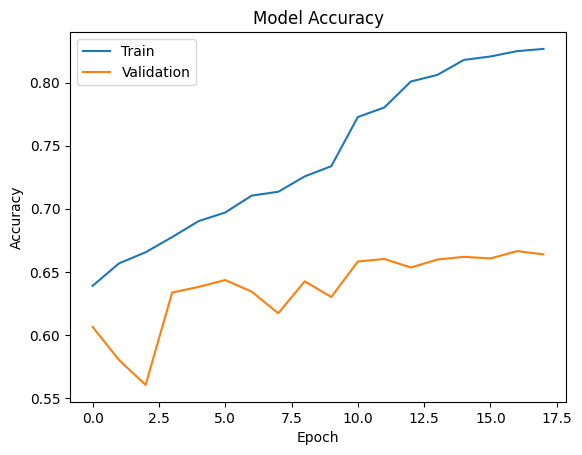

In [53]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

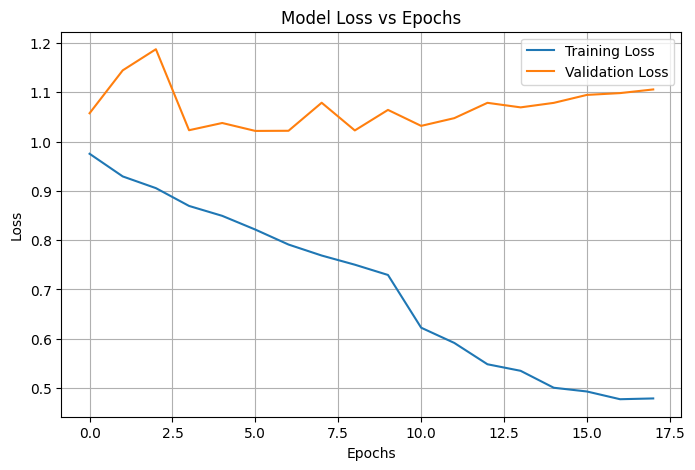

In [54]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [55]:
from tensorflow.keras.utils import load_img
import numpy as np

def ef(image):
    img = load_img(
        image,
        color_mode="grayscale",
        target_size=(48,48)
    )

    feature = np.array(img)
    feature = feature.reshape(1,48,48,1)

    return feature / 255.0

In [56]:
label = ['angry','disgust','fear','happy','neutral','sad','surprise']

Original image is sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Model prediction is: fear


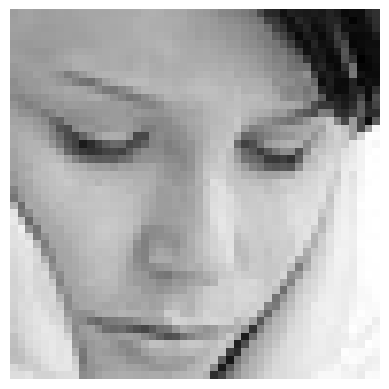

In [61]:
import matplotlib.pyplot as plt

image = 'images/train/sad/42.jpg'

print("Original image is sad")

img = ef(image)

pred = model.predict(img)
pred_label = label[pred.argmax()]

print("Model prediction is:", pred_label)

plt.imshow(img.reshape(48,48), cmap='gray')
plt.axis('off')
plt.show()

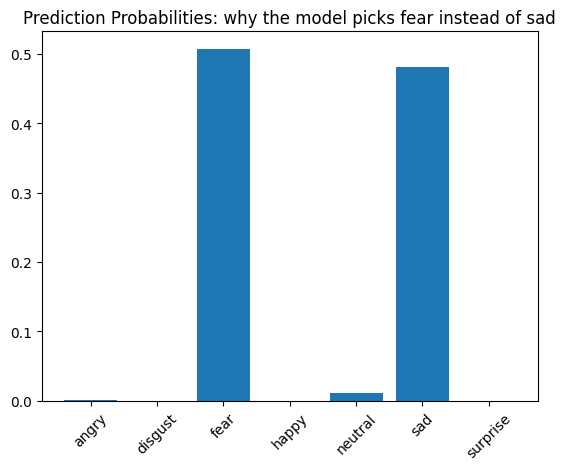

In [62]:
import matplotlib.pyplot as plt

plt.bar(label, pred[0])
plt.title("Prediction Probabilities: why the model picks fear instead of sad")
plt.xticks(rotation=45)
plt.show()


Original image: sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Model prediction: sad


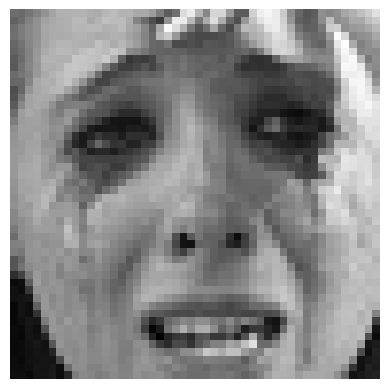


Original image: fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Model prediction: fear


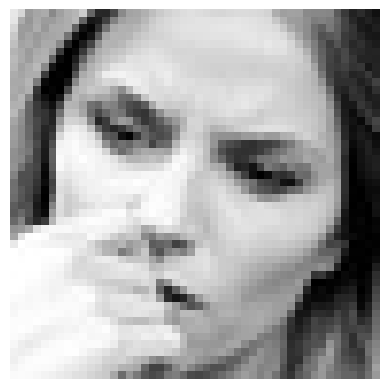


Original image: disgust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Model prediction: disgust


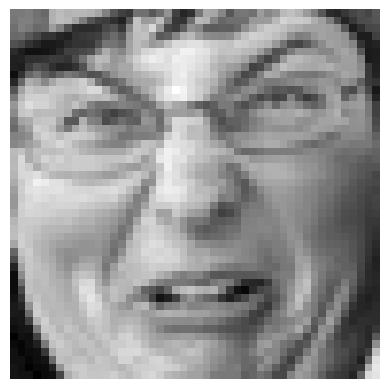


Original image: happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Model prediction: happy


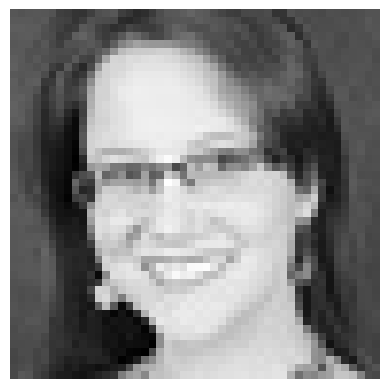


Original image: surprise
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Model prediction: surprise


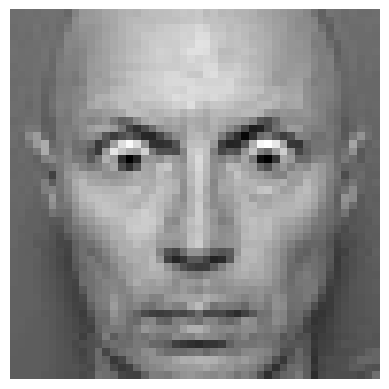

In [66]:
test_images = [
    ('images/train/sad/54.jpg','sad'),
    ('images/train/fear/2.jpg','fear'),
    ('images/train/disgust/299.jpg','disgust'),
    ('images/train/happy/7.jpg','happy'),
    ('images/train/surprise/15.jpg','surprise')
]

for path, true_label in test_images:
    print("\nOriginal image:", true_label)

    img = ef(path)
    pred = model.predict(img)
    pred_label = label[pred.argmax()]

    print("Model prediction:", pred_label)

    plt.imshow(img.reshape(48,48), cmap='gray')
    plt.axis('off')
    plt.show()